### Import statements

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.formula.api import ols
import pandas as pd

## Sensor calibration

### Subcritical sensor calibration curve

b0 = 36.867167582476284
b1 = 2.2729171352478246


Text(0, 0.5, 'Water level (cm)')

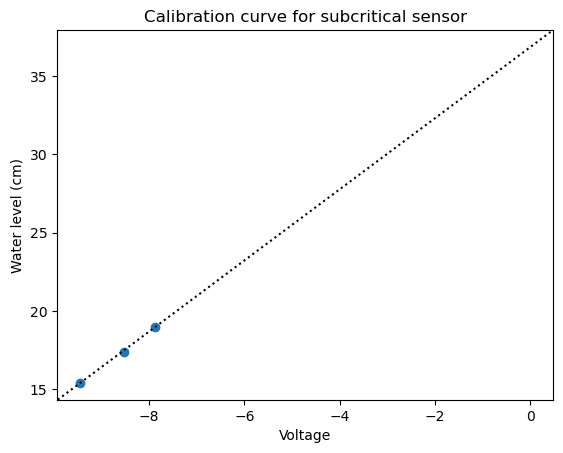

In [16]:
# calibration data
sub_voltage = np.array([-9.4592, -8.5297, -7.8816])
sub_height = np.array([15.4, 17.4, 19])                     # cm
sub_df = pd.DataFrame({'Voltage':sub_voltage, 'Height':sub_height})

# linear fit
sub_calibration = ols('Height ~ Voltage', data=sub_df).fit()
sub_b0, sub_b1 = sub_calibration.params
print(f'b0 = {sub_b0}')
print(f'b1 = {sub_b1}')

# plot
plt.scatter(sub_voltage, sub_height)
plt.axline(xy1=(0,sub_b0), slope=sub_b1, color='black', linestyle=':')
plt.title('Calibration curve for subcritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Supercritical sensor calibration curve

b0 = 28.6137223023922
b1 = 2.2998132138163467


Text(0, 0.5, 'Water level (cm)')

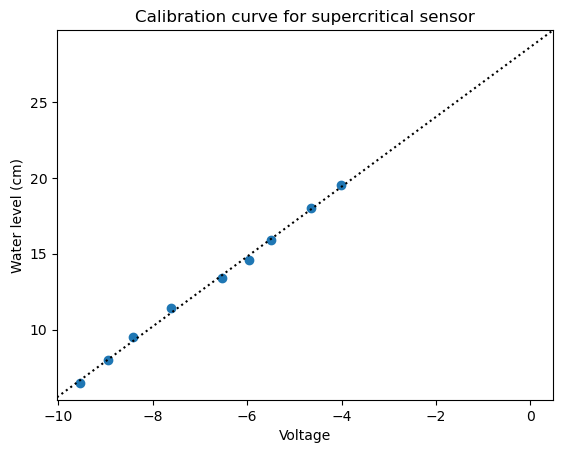

In [17]:
# calibration data
super_voltage = np.array([-9.5491, -8.9420, -8.4136, -7.6184, -6.5391, -5.9702, -5.4983, -4.6409, -4.0175])
super_height = np.array([6.5, 8, 9.5, 11.4, 13.4, 14.6, 15.9, 18, 19.5])    # cm
super_df = pd.DataFrame({'Voltage':super_voltage, 'Height':super_height})

# linear fit
super_calibration = ols('Height ~ Voltage', data=super_df).fit()
super_b0, super_b1 = super_calibration.params
print(f'b0 = {super_b0}')
print(f'b1 = {super_b1}')

# plot
plt.scatter(super_voltage, super_height)
plt.axline(xy1=(0,super_b0), slope=super_b1, color='black', linestyle=':')
plt.title('Calibration curve for supercritical sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

### Head tank sensor calibration curve

b0 = 59.58499679931716
b1 = 2.0198975781500033


Text(0, 0.5, 'Water level (cm)')

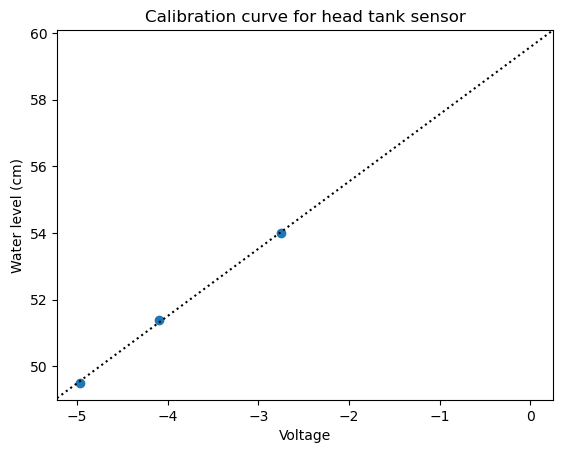

In [18]:
# calibration data
head_voltage = np.array([-2.75, -4.09, -4.97])
head_distance = np.array([9.6, 12.2, 14.1])    # cm, sensor distance from water surface
head_df = pd.DataFrame({'Voltage':head_voltage, 'Distance':head_distance})

# convert distance from water surface to water level
head_df['Height'] = 63.6 - head_df['Distance']

# linear fit
head_calibration = ols('Height ~ Voltage', data=head_df).fit()
head_b0, head_b1 = head_calibration.params
print(f'b0 = {head_b0}')
print(f'b1 = {head_b1}')

# plot
plt.scatter(head_df['Voltage'], head_df['Height'])
plt.axline(xy1=(0,head_b0), slope=head_b1, color='black', linestyle=':')
plt.title('Calibration curve for head tank sensor')
plt.xlabel('Voltage')
plt.ylabel('Water level (cm)')

## Load data

### Read csv files

In [19]:
import glob

csv_files = sorted(glob.glob('*.csv'))
dfs = []

for file_name in csv_files:
    try:
        df = pd.read_csv(file_name)
        dfs.append(df)
        print(f"Successfully read: {file_name}")
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

V_ai0 = np.empty(len(csv_files))
V_ai1 = np.empty(len(csv_files))
V_ai2 = np.empty(len(csv_files))

for i, df in enumerate(dfs):
    V_ai0[i] = df['V_ai0'].mean()
    V_ai1[i] = df['V_ai1'].mean()
    V_ai2[i] = df['V_ai2'].mean()

sensor_data = pd.DataFrame({'V_ai0': V_ai0, 'V_ai1': V_ai1, 'V_ai2': V_ai2}) # note that trial indices are one less than the ones I wrote in the notebook
sensor_data = sensor_data.drop(0)

Successfully read: 2025-10-10_10-51-25_sensor_data.csv
Successfully read: 2025-10-10_10-56-53_sensor_data.csv
Successfully read: 2025-10-10_11-00-59_sensor_data.csv
Successfully read: 2025-10-10_11-03-29_sensor_data.csv
Successfully read: 2025-10-10_11-06-35_sensor_data.csv
Successfully read: 2025-10-10_11-10-33_sensor_data.csv


### Convert voltages to water heights

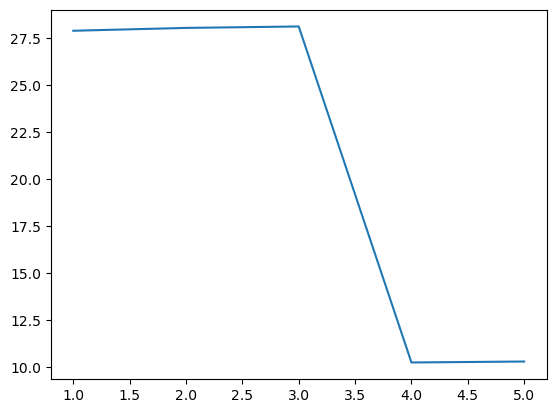

In [20]:
sensor_data['Supercritical Height (cm)'] = super_b0 + super_b1 * sensor_data['V_ai1'] # DOUBLE CHECK IF YOU MATCHED THESE CORRECTLY

plt.plot(sensor_data['Supercritical Height (cm)'])


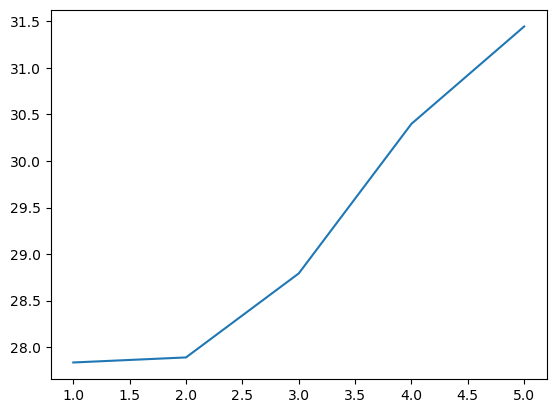

In [21]:
sensor_data['Subcritical Height (cm)'] = sub_b0 + sub_b1 * sensor_data['V_ai0']

plt.plot(sensor_data['Subcritical Height (cm)'])

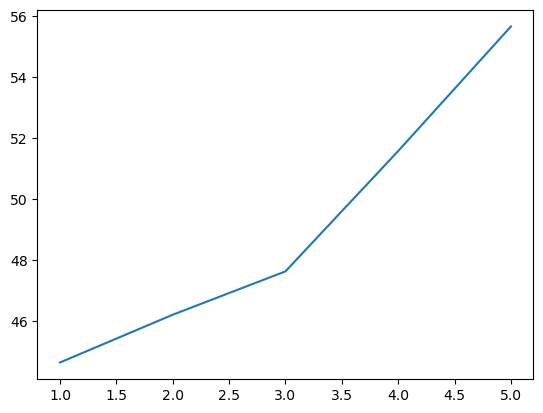

In [22]:
sensor_data['Head Tank Height (cm)'] = head_b0 + head_b1 * sensor_data['V_ai2']

plt.plot(sensor_data['Head Tank Height (cm)'])

### Plot the curves together

Text(0, 0.5, 'Water level (cm)')

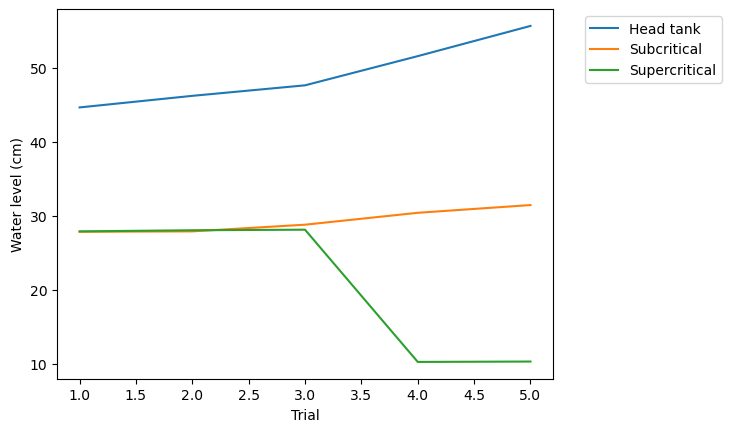

In [23]:
plt.plot(sensor_data['Head Tank Height (cm)'])
plt.plot(sensor_data['Subcritical Height (cm)'])
plt.plot(sensor_data['Supercritical Height (cm)'])


plt.legend(['Head tank', 'Subcritical', 'Supercritical'], bbox_to_anchor=(1.05, 1))
plt.xlabel('Trial')
plt.ylabel('Water level (cm)')

## Stage discharge curve

### Calculate discharge

In [24]:
sensor_data['Delta P'] = np.array([76, 84, 93, 103, 112.5]) # from venturi meter

sensor_data['Q (m3/s)'] = 0.1753*(sensor_data['Delta P']/75.36)**(1/2)

### Calculate head difference

In [25]:
sensor_data['Head diff (cm)'] = sensor_data['Head Tank Height (cm)'] - sensor_data['Subcritical Height (cm)']

### Graph stage vs discharge 

In [26]:
import seaborn as sns

,V_ai0,V_ai1,V_ai2,Supercritical Height (cm),Subcritical Height (cm),Head Tank Height (cm),Delta P,Q (m3/s),Head diff (cm)
1,-3.973797,-0.315042,-7.401165,27.889185,27.835055,44.635402,76.0,0.176043,16.800347
2,-3.949961,-0.249274,-6.626229,28.040438,27.889235,46.200694,84.0,0.185076,18.311459
3,-3.552951,-0.216199,-5.922805,28.116504,28.791605,47.621537,93.0,0.194739,18.829932
4,-2.845716,-7.984570,-3.970188,10.250702,30.399090,51.565623,103.0,0.204942,21.166533
5,-2.385560,-7.962322,-1.949319,10.301868,31.444988,55.647572,112.5,0.214184,24.202584


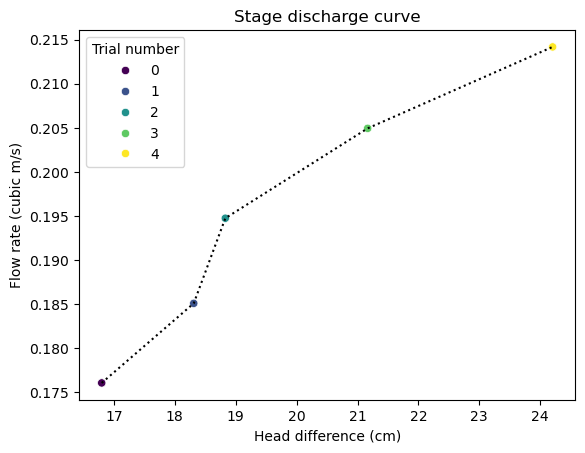

In [27]:
sns.scatterplot(x='Head diff (cm)', y='Q (m3/s)', hue=np.arange(0, len(sensor_data)), data=sensor_data, palette='viridis')
plt.plot(sensor_data['Head diff (cm)'], sensor_data['Q (m3/s)'], color='black', linestyle=':')
#sns.lineplot(x='Head diff (cm)', y='Delta P', data=sensor_data)
plt.xlabel('Head difference (cm)')
plt.ylabel('Flow rate (cubic m/s)')
plt.legend(title='Trial number')
plt.title('Stage discharge curve')

display(sensor_data)